In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

## Import Dataset

In [2]:
df1=pd.read_csv('/kaggle/input/datasets/shilongzhuang/telecom-customer-churn-by-maven-analytics/telecom_customer_churn.csv')

In [3]:
df = df1.copy()

In [4]:
df.head(5)

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [5]:
df.shape

(7043, 38)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   object 
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   object 
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                              3166 non-null   objec

## Dataset Column Summary

| Column Name | Description |
|---|---|
| Customer ID | Unique identifier for each customer |
| Gender | Customer gender (Male/Female) |
| Age | Age of the customer |
| Married | Whether customer is married |
| Number of Dependents | Number of dependents linked to customer |
| City | Customer's city/location |
| Zip Code | Area ZIP code |
| Latitude | Geographic latitude of customer |
| Longitude | Geographic longitude of customer |
| Number of Referrals | How many customers this customer referred |
| Tenure in Months | Number of months customer stayed with company |
| Offer | Promotional offer given to customer |
| Phone Service | Whether customer uses phone service |
| Avg Monthly Long Distance Charges | Average monthly long-distance call charges |
| Multiple Lines | Whether customer has multiple phone lines |
| Internet Service | Whether customer uses internet service |
| Internet Type | Type of internet connection (DSL/Fiber/Cable) |
| Avg Monthly GB Download | Average internet data downloaded per month |
| Online Security | Whether online security service is enabled |
| Online Backup | Whether online backup service is enabled |
| Device Protection Plan | Whether device protection plan is active |
| Premium Tech Support | Whether premium technical support is active |
| Streaming TV | Whether customer streams TV services |
| Streaming Movies | Whether customer streams movies |
| Streaming Music | Whether customer streams music |
| Unlimited Data | Whether unlimited internet data plan is active |
| Contract | Contract type (Month-to-Month, One Year, Two Year) |
| Paperless Billing | Whether customer uses paperless billing |
| Payment Method | Customer payment method |
| Monthly Charge | Monthly bill amount |
| Total Charges | Total charges accumulated by customer (Total Charges ≈ Monthly Charge × Tenure) |
| Total Refunds | Total refunded amount to customer |
| Total Extra Data Charges | Extra charges due to additional data usage |
| Total Long Distance Charges | Total long-distance call charges |
| Total Revenue | Total revenue generated from customer |
| Customer Status | Final customer state (Stayed, Joined, Churned) |
| Churn Category | High-level reason category for churn |
| Churn Reason | Specific reason why customer churned |

In [7]:
df.nunique()

Customer ID                          7043
Gender                                  2
Age                                    62
Married                                 2
Number of Dependents                   10
City                                 1106
Zip Code                             1626
Latitude                             1626
Longitude                            1625
Number of Referrals                    12
Tenure in Months                       72
Offer                                   5
Phone Service                           2
Avg Monthly Long Distance Charges    3583
Multiple Lines                          2
Internet Service                        2
Internet Type                           3
Avg Monthly GB Download                49
Online Security                         2
Online Backup                           2
Device Protection Plan                  2
Premium Tech Support                    2
Streaming TV                            2
Streaming Movies                  

In [8]:
df.isnull().sum()

Customer ID                             0
Gender                                  0
Age                                     0
Married                                 0
Number of Dependents                    0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges     682
Multiple Lines                        682
Internet Service                        0
Internet Type                        1526
Avg Monthly GB Download              1526
Online Security                      1526
Online Backup                        1526
Device Protection Plan               1526
Premium Tech Support                 1526
Streaming TV                         1526
Streaming Movies                  

### Dropping unnecessary columns
#### Churn Reason and Churn Category are data leakage because they only exist AFTER churn happened.

#### Dropping city column as well because:
<ol>
    <li>too many unique cities</li>
    <li>sparse one-hot encoding</li>
    <li>weak predictive value</li>
    <li>unnecessary complexity</li>
</ol>

In [9]:
drop_cols = [
    'Customer ID',
    'Latitude',
    'Longitude',
    'Zip Code',
    'Churn Category',
    'Churn Reason',
    'City'
]

df.drop(columns=drop_cols, inplace=True)

### Converting Target Variables to 0/1
<ul>
    <li>Stayed  : 0</li>
    <li>Joined  : 0</li>
    <li>Churned : 1</li>
</ul>

In [10]:
df['Customer Status'] = df['Customer Status'].replace({
    'Stayed': 0,
    'Joined': 0,
    'Churned': 1
}).astype(int)

/tmp/ipykernel_57/18028637.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Customer Status'] = df['Customer Status'].replace({


### Handling Missing Values

For missing values in the "Offer" column, we replace them with "No Offer".

In [11]:
df['Offer'] = df['Offer'].fillna('No Offer')

For the internet-related columns — "Internet Type", "Online Security", "Online Backup", "Device Protection Plan", "Premium Tech Support", "Streaming TV", "Streaming Movies", "Streaming Music", and "Unlimited Data" — missing values occur because the customer has no internet service. Therefore, these missing values are replaced with "No Internet".

In [12]:
internet_cols = [
    'Internet Type',
    'Online Security',
    'Online Backup',
    'Device Protection Plan',
    'Premium Tech Support',
    'Streaming TV',
    'Streaming Movies',
    'Streaming Music',
    'Unlimited Data'
]

for col in internet_cols:
    df[col] = df[col].fillna('No Internet')

In [13]:
df['Multiple Lines'].value_counts(dropna=False)

Multiple Lines
No     3390
Yes    2971
NaN     682
Name: count, dtype: int64

In [14]:
df[df['Multiple Lines'].isnull()]['Phone Service'].value_counts()

Phone Service
No    682
Name: count, dtype: int64

Missing values in the "Multiple Lines" column are not random. Customers with missing values do not have phone service; therefore, we replace NaN values with "No Phone Service" instead of dropping the rows.

In [15]:
df['Multiple Lines'] = df['Multiple Lines'].fillna('No Phone Service')

In [16]:
df[df['Avg Monthly Long Distance Charges'].isnull()]['Multiple Lines'].value_counts()

Multiple Lines
No Phone Service    682
Name: count, dtype: int64

This occurs because customers with no service have their average monthly long-distance charges set to null. Since no charges are incurred, these values should be replaced with 0.

In [17]:
df['Avg Monthly Long Distance Charges'] = df['Avg Monthly Long Distance Charges'].fillna(0)

In [18]:
df[df['Avg Monthly GB Download'].isnull()]['Internet Type'].value_counts()

Internet Type
No Internet    1526
Name: count, dtype: int64

This occurs because customers with no internet service have their average monthly GB download value set to NULL. Since no internet data is used, these values should be replaced with 0.

In [19]:
df['Avg Monthly GB Download'] = df['Avg Monthly GB Download'].fillna(0)

## Feature Engineering

#### Adding new Features

##### Total Services feature

In [20]:
service_cols = [
    'Phone Service',
    'Multiple Lines',
    'Internet Service',
    'Online Security',
    'Online Backup',
    'Device Protection Plan',
    'Premium Tech Support',
    'Streaming TV',
    'Streaming Movies',
    'Streaming Music',
    'Unlimited Data'
]

df['TotalServices'] = 0

for col in service_cols:
    df['TotalServices'] += df[col].isin(['Yes']).astype(int)

##### Tenure Group

In [21]:
def tenure_group(months):
    if months <= 12:
        return 'New'
    elif months <= 24:
        return 'Regular'
    elif months <= 48:
        return 'Loyal'
    else:
        return 'Long-Term'

df['TenureGroup'] = df['Tenure in Months'].apply(tenure_group)

##### Avg Charge Per Service

In [22]:
df['AvgChargePerService'] = (
    df['Monthly Charge'] / (df['TotalServices'] + 1)
)

##### Auto Payment Flag

In [23]:
df['Payment Method'].value_counts()

Payment Method
Bank Withdrawal    3909
Credit Card        2749
Mailed Check        385
Name: count, dtype: int64

In [24]:
df['AutoPayment'] = df['Payment Method'].isin([
    'Credit Card',
    'Bank Withdrawal'
]).astype(int)

In [25]:
print(df.isnull().sum())

Gender                               0
Age                                  0
Married                              0
Number of Dependents                 0
Number of Referrals                  0
Tenure in Months                     0
Offer                                0
Phone Service                        0
Avg Monthly Long Distance Charges    0
Multiple Lines                       0
Internet Service                     0
Internet Type                        0
Avg Monthly GB Download              0
Online Security                      0
Online Backup                        0
Device Protection Plan               0
Premium Tech Support                 0
Streaming TV                         0
Streaming Movies                     0
Streaming Music                      0
Unlimited Data                       0
Contract                             0
Paperless Billing                    0
Payment Method                       0
Monthly Charge                       0
Total Charges            

### Binary Encoding for binary features

In [26]:
binary_cols = [
    'Gender',
    'Married',
    'Phone Service',
    'Paperless Billing'
]

for col in binary_cols:
    df[col] = df[col].map({
        'Yes': 1,
        'No': 0,
        'Male': 1,
        'Female': 0
    })

### One Hot Encoding for categorical features

drop_first = True reduces multicollinearity<br>
multicollinearity means some features are highly dependent on other features

In [27]:
categorical_cols = df.select_dtypes(include='object').columns

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 54 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Gender                              7043 non-null   int64  
 1   Age                                 7043 non-null   int64  
 2   Married                             7043 non-null   int64  
 3   Number of Dependents                7043 non-null   int64  
 4   Number of Referrals                 7043 non-null   int64  
 5   Tenure in Months                    7043 non-null   int64  
 6   Phone Service                       7043 non-null   int64  
 7   Avg Monthly Long Distance Charges   7043 non-null   float64
 8   Avg Monthly GB Download             7043 non-null   float64
 9   Paperless Billing                   7043 non-null   int64  
 10  Monthly Charge                      7043 non-null   float64
 11  Total Charges                       7043 no

## Correlation Analysis for numeric features

In [29]:
corr_cols = [
    'Age',
    'Number of Dependents',
    'Number of Referrals',
    'Tenure in Months',
    'Avg Monthly Long Distance Charges',
    'Avg Monthly GB Download',
    'Monthly Charge',
    'Total Charges',
    'Total Extra Data Charges',
    'Total Long Distance Charges',
    'Total Revenue',
    'TotalServices',
    'AvgChargePerService',
    'Customer Status'
]

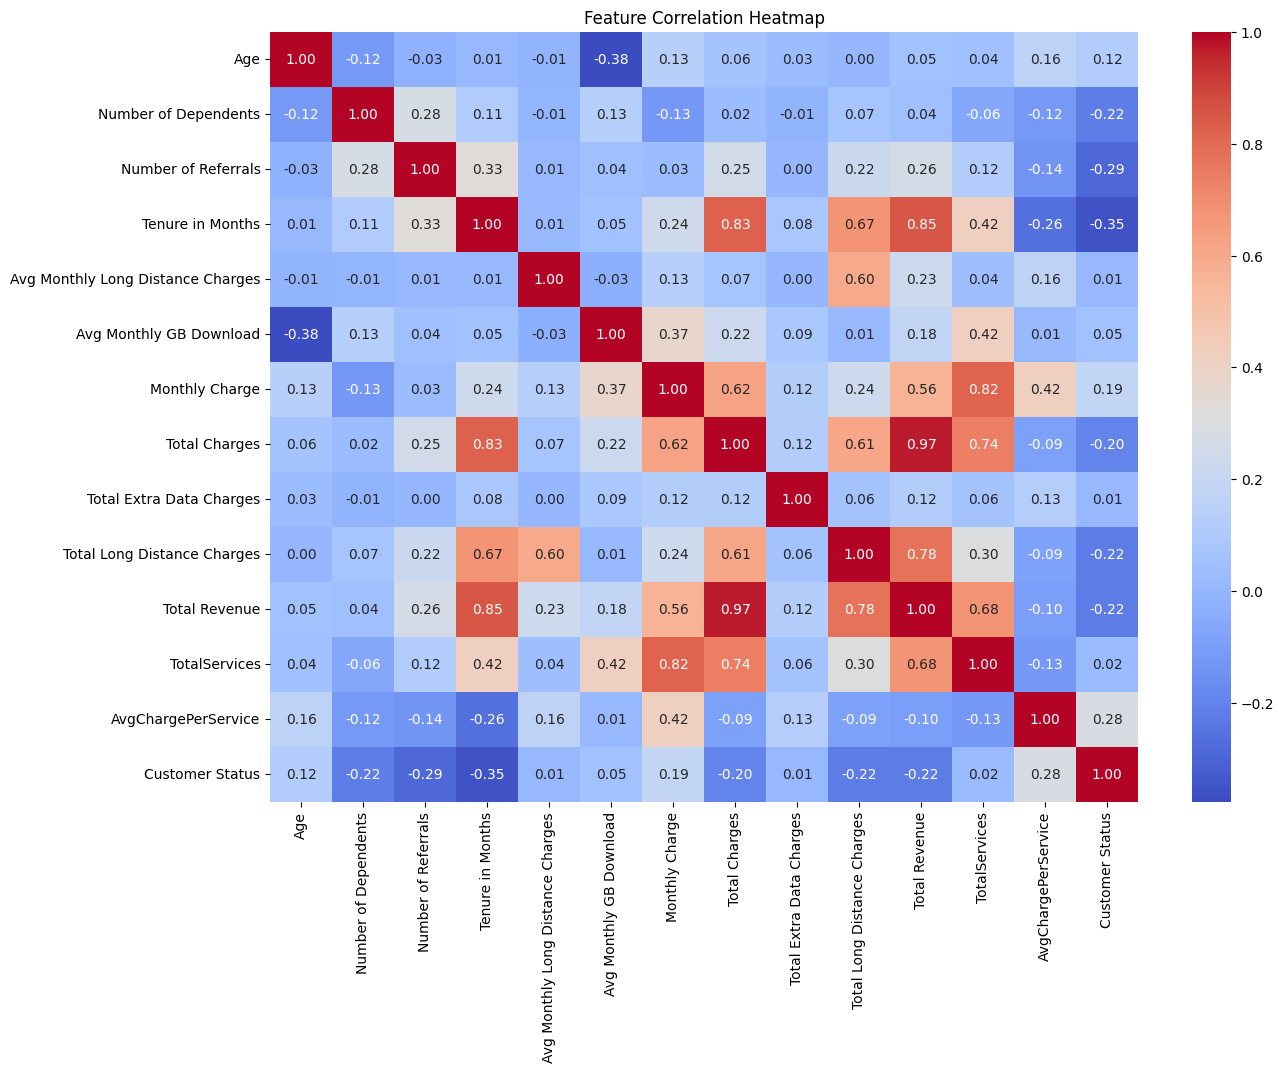

In [30]:
plt.figure(figsize=(14,10))

correlation_matrix = df[corr_cols].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Feature Correlation Heatmap')

plt.show()

However, 4 out of the 5 model in this notebook are tree based model which are robust to feature correlation so we won't be doing feature droping based on correlation analysis

## Separating Feature and Target

In [31]:
X = df.drop('Customer Status', axis=1)
y = df['Customer Status']

## Train Test Split

We need to use stratify as class is highly imbalanced<br>
Stratify: maintain same class proportions in train,val and test set

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [33]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

In [104]:
X_train.columns

Index(['Gender', 'Age', 'Married', 'Number of Dependents',
       'Number of Referrals', 'Tenure in Months', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download',
       'Paperless Billing', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'TotalServices', 'AvgChargePerService', 'AutoPayment',
       'Offer_Offer A', 'Offer_Offer B', 'Offer_Offer C', 'Offer_Offer D',
       'Offer_Offer E', 'Multiple Lines_No Phone Service',
       'Multiple Lines_Yes', 'Internet Service_Yes', 'Internet Type_DSL',
       'Internet Type_Fiber Optic', 'Internet Type_No Internet',
       'Online Security_No Internet', 'Online Security_Yes',
       'Online Backup_No Internet', 'Online Backup_Yes',
       'Device Protection Plan_No Internet', 'Device Protection Plan_Yes',
       'Premium Tech Support_No Internet', 'Premium Tech Support_Yes',
       'Streaming TV_No Internet', 'Strea

## Scaling

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

## Model

In [35]:
!pip install lightgbm catboost -q

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

### Evaluation model Function

In [37]:
def evaluate_model(model, X_train, y_train, X_val, y_val, model_name):
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_val)
    
    y_prob = model.predict_proba(X_val)[:, 1]
    
    # Metrics
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_prob)
    
    print(f"{model_name}")
    
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC-AUC   : {roc_auc:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred))
    
    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC-AUC': roc_auc
    }

### 1) Logistic Regression Model

In [38]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

### 2) Random Forest Model

In [39]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

### 3) XGBoost

In [40]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

### 4) LightGBM 

In [41]:
lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

### 5) CatBoost

In [42]:
cat_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.05,
    depth=6,
    verbose=0,
    random_state=42
)

## Train and Evaluate Model

In [43]:
results = []

results.append(
    evaluate_model(
        lr_model,
        X_train_scaled,
        y_train,
        X_val_scaled,
        y_val,
        "Logistic Regression"
    )
)

Logistic Regression
Accuracy  : 0.8220
Precision : 0.6620
Recall    : 0.6714
F1 Score  : 0.6667
ROC-AUC   : 0.8858

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       776
           1       0.66      0.67      0.67       280

    accuracy                           0.82      1056
   macro avg       0.77      0.77      0.77      1056
weighted avg       0.82      0.82      0.82      1056



In [44]:
results.append(
    evaluate_model(
        rf_model,
        X_train,
        y_train,
        X_val,
        y_val,
        "Random Forest"
    )
)

Random Forest
Accuracy  : 0.8295
Precision : 0.7016
Recall    : 0.6214
F1 Score  : 0.6591
ROC-AUC   : 0.8871

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.90      0.89       776
           1       0.70      0.62      0.66       280

    accuracy                           0.83      1056
   macro avg       0.79      0.76      0.77      1056
weighted avg       0.82      0.83      0.83      1056



In [45]:
results.append(
    evaluate_model(
        xgb_model,
        X_train,
        y_train,
        X_val,
        y_val,
        "XGBoost"
    )
)

XGBoost
Accuracy  : 0.8438
Precision : 0.7186
Recall    : 0.6750
F1 Score  : 0.6961
ROC-AUC   : 0.8993

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.90      0.89       776
           1       0.72      0.68      0.70       280

    accuracy                           0.84      1056
   macro avg       0.80      0.79      0.80      1056
weighted avg       0.84      0.84      0.84      1056



In [46]:
results.append(
    evaluate_model(
        lgbm_model,
        X_train,
        y_train,
        X_val,
        y_val,
        "LightGBM"
    )
)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1308, number of negative: 3622
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001393 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1960
[LightGBM] [Info] Number of data points in the train set: 4930, number of used features: 53
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265314 -> initscore=-1.018527
[LightGBM] [Info] Start training from score -1.018527
LightGBM
Accuracy  : 0.8400
Precision : 0.7033
Recall    : 0.6857
F1 Score  : 0.6944
ROC-AUC   : 0.8996

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.90      0.89       776
           1       0.70      0.69      0.69       280

    accuracy                           0.84      1056
   macro avg       

In [47]:
results.append(
    evaluate_model(
        cat_model,
        X_train,
        y_train,
        X_val,
        y_val,
        "CatBoost"
    )
)

CatBoost
Accuracy  : 0.8352
Precision : 0.7070
Recall    : 0.6464
F1 Score  : 0.6754
ROC-AUC   : 0.9012

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.90      0.89       776
           1       0.71      0.65      0.68       280

    accuracy                           0.84      1056
   macro avg       0.79      0.77      0.78      1056
weighted avg       0.83      0.84      0.83      1056



### Compare Results

In [48]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='ROC-AUC',
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
4,CatBoost,0.835227,0.707031,0.646429,0.675373,0.901206
3,LightGBM,0.839962,0.703297,0.685714,0.694394,0.899577
2,XGBoost,0.843750,0.718631,0.675000,0.696133,0.899291
1,Random Forest,0.829545,0.701613,0.621429,0.659091,0.887104
0,Logistic Regression,0.821970,0.661972,0.671429,0.666667,0.885756


### Confusion Matrix Function

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(model, X, y, model_name):
    
    y_pred = model.predict(X)
    
    cm = confusion_matrix(y, y_pred)
    
    plt.figure(figsize=(6,5))
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )
    
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    
    plt.show()

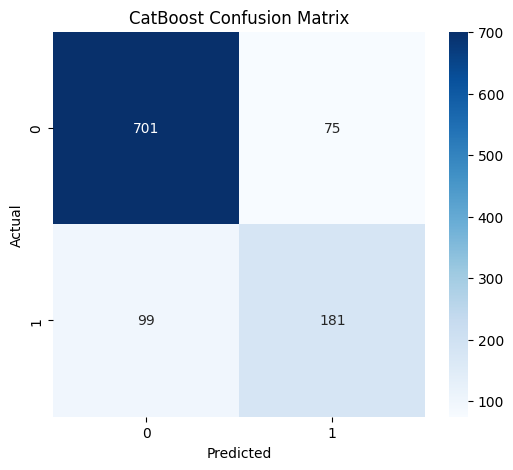

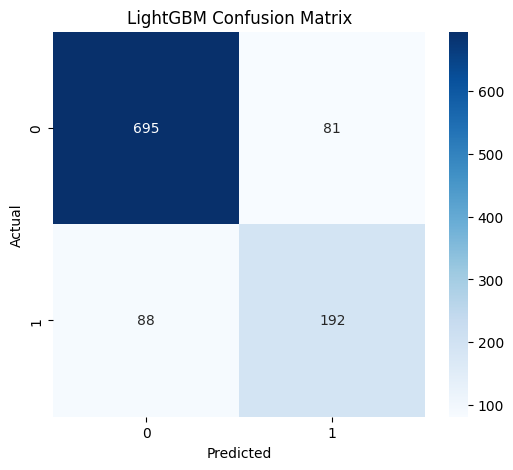

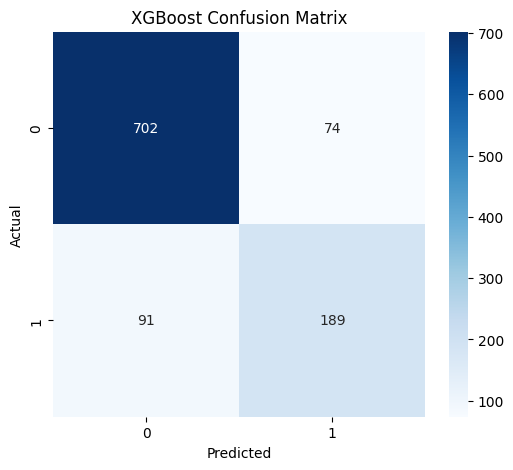

In [50]:
plot_confusion_matrix(cat_model, X_val, y_val, "CatBoost")
plot_confusion_matrix(lgbm_model, X_val, y_val, "LightGBM")
plot_confusion_matrix(xgb_model, X_val, y_val, "XGBoost")

### ROC curve comparison

Optimal threshold for Model CatBoost: 0.30159830376707497
Optimal threshold for Model LightGBM: 0.24365980360384373
Optimal threshold for Model XGBoost: 0.28746814


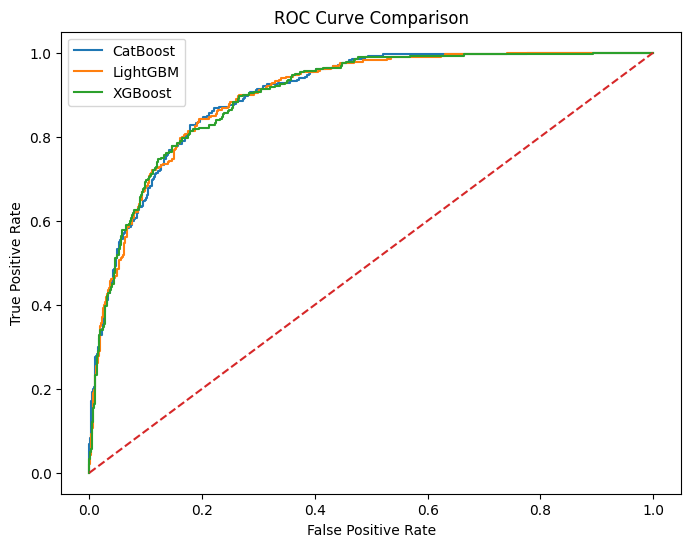

In [52]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

models = {
    'CatBoost': cat_model,
    'LightGBM': lgbm_model,
    'XGBoost': xgb_model
}

for name, model in models.items():
    
    y_prob = model.predict_proba(X_val)[:,1]
    
    fpr, tpr, thresholds = roc_curve(y_val, y_prob)

    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]
    print(f"Optimal threshold for Model {name}:", optimal_threshold)

    
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')

plt.legend()

plt.show()

### Preliminary Feature Importance

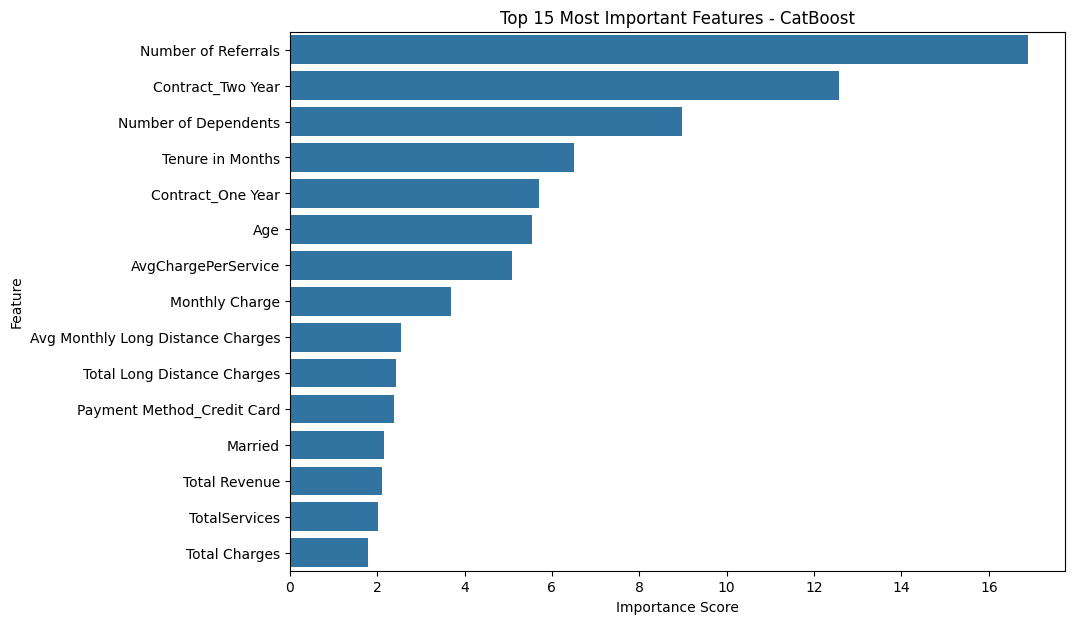

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importance = cat_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

top_features = feature_importance_df.head(15)

plt.figure(figsize=(10,7))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title('Top 15 Most Important Features - CatBoost')

plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.show()

In [54]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(4930, 53)
(1056, 53)
(1057, 53)


In [55]:
print(y_train.value_counts(normalize=True))
print(y_val.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Customer Status
0    0.734686
1    0.265314
Name: proportion, dtype: float64
Customer Status
0    0.734848
1    0.265152
Name: proportion, dtype: float64
Customer Status
0    0.734153
1    0.265847
Name: proportion, dtype: float64


## Parameter Tuning

We will only tune parameters for the 3 best models i.e. XGBoost, LightGBM, CatBoost

In [56]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score

### XG Boost Tuning

In [57]:
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3]
}

In [58]:
xgb_random = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    param_distributions=xgb_params,
    n_iter=50,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [59]:
xgb_random.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'gamma': [0, 0.1, 0.3],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='roc_auc', verbose=1)

In [60]:
print("Best XGBoost Params:")
print(xgb_random.best_params_)

Best XGBoost Params:
{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 0.8}


In [61]:
best_xgb = xgb_random.best_estimator_

y_prob = best_xgb.predict_proba(X_val)[:,1]

roc_auc = roc_auc_score(y_val, y_prob)

print("XGBoost Validation ROC-AUC:", roc_auc)

XGBoost Validation ROC-AUC: 0.8985364506627392


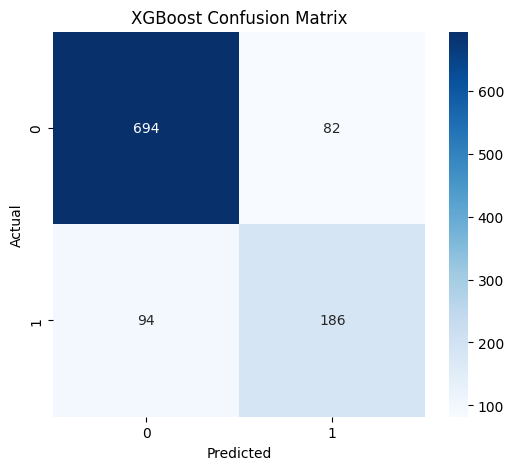

In [62]:
plot_confusion_matrix(best_xgb, X_val, y_val, "XGBoost")

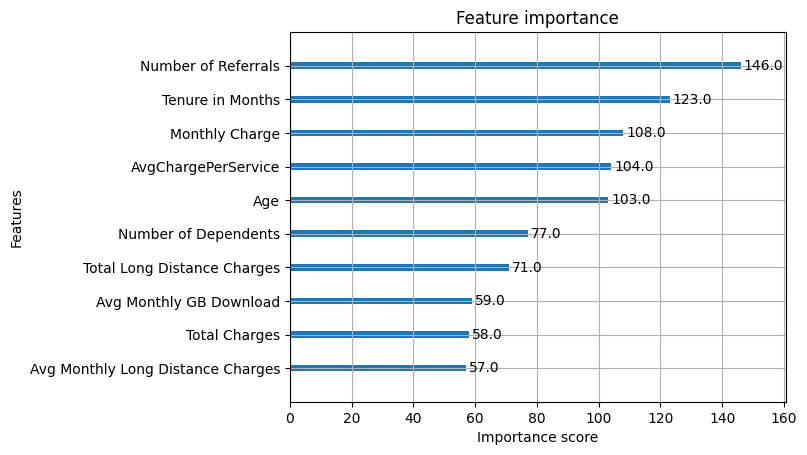

In [63]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(best_xgb, max_num_features=10)
plt.show()

The above feature importance curve show there is no data leak.

### LIGHTGBM TUNING

In [64]:
lgbm_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, -1],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [20, 31, 50],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

In [65]:
lgbm_random = RandomizedSearchCV(
    estimator=LGBMClassifier(
        random_state=42,
        verbosity=-1
    ),
    
    param_distributions=lgbm_params,
    
    n_iter=50,
    
    scoring='roc_auc',
    
    cv=3,
    
    verbose=1,
    
    random_state=42,
    
    n_jobs=-1
)

In [66]:
lgbm_random.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


RandomizedSearchCV(cv=3,
                   estimator=LGBMClassifier(random_state=42, verbosity=-1),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 5, 7, -1],
                                        'n_estimators': [100, 200, 300],
                                        'num_leaves': [20, 31, 50],
                                        'subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='roc_auc', verbose=1)

In [67]:
print("Best LightGBM Params:")
print(lgbm_random.best_params_)

Best LightGBM Params:
{'subsample': 1.0, 'num_leaves': 20, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


In [68]:
best_lgbm = lgbm_random.best_estimator_

y_prob = best_lgbm.predict_proba(X_val)[:,1]

roc_auc = roc_auc_score(y_val, y_prob)

print("LightGBM Validation ROC-AUC:", roc_auc)

LightGBM Validation ROC-AUC: 0.8995880891016201


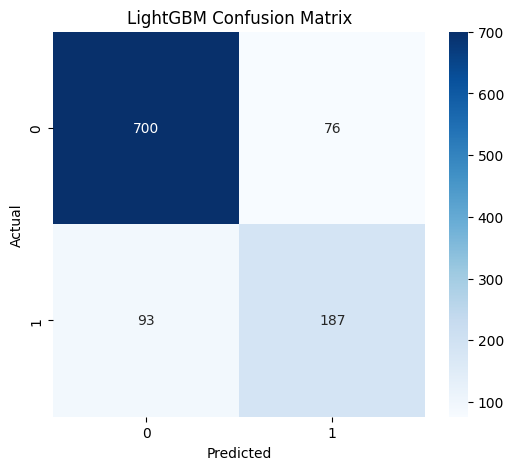

In [69]:
plot_confusion_matrix(best_lgbm, X_val, y_val, "LightGBM")

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

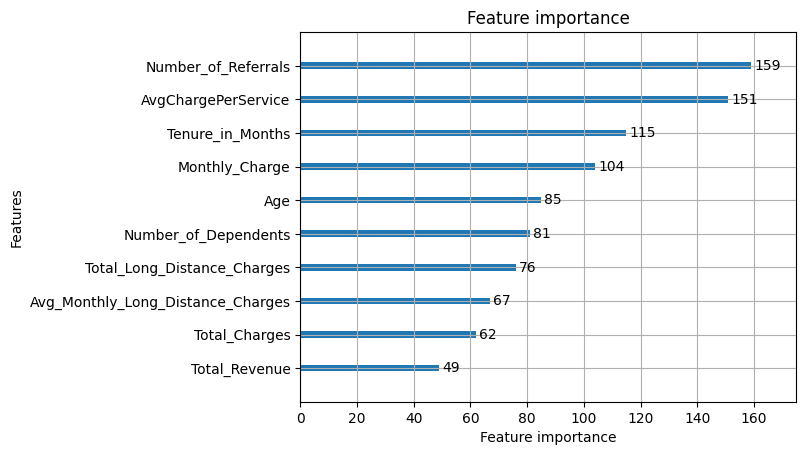

In [70]:
from lightgbm import plot_importance
plot_importance(best_lgbm,max_num_features=10)

### 3. CATBOOST TUNING

In [71]:
cat_params = {
    'iterations': [100, 200, 300],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5, 7],
    'border_count': [32, 64, 128]
}

In [72]:
cat_random = RandomizedSearchCV(
    estimator=CatBoostClassifier(
        verbose=0,
        random_state=42
    ),
    
    param_distributions=cat_params,
    
    n_iter=50,
    
    scoring='roc_auc',
    
    cv=3,
    
    verbose=1,
    
    random_state=42,
    
    n_jobs=-1
)

In [73]:
cat_random.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


RandomizedSearchCV(cv=3,
                   estimator=CatBoostClassifier(random_state=42, verbose=0),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'border_count': [32, 64, 128],
                                        'depth': [4, 6, 8],
                                        'iterations': [100, 200, 300],
                                        'l2_leaf_reg': [1, 3, 5, 7],
                                        'learning_rate': [0.01, 0.05, 0.1]},
                   random_state=42, scoring='roc_auc', verbose=1)

In [74]:
print("Best CatBoost Params:")
print(cat_random.best_params_)

Best CatBoost Params:
{'learning_rate': 0.05, 'l2_leaf_reg': 3, 'iterations': 200, 'depth': 4, 'border_count': 64}


In [75]:
best_cat = cat_random.best_estimator_

y_prob = best_cat.predict_proba(X_val)[:,1]

roc_auc = roc_auc_score(y_val, y_prob)

print("CatBoost Validation ROC-AUC:", roc_auc)

CatBoost Validation ROC-AUC: 0.9023472017673048


In [76]:
y_pred = best_cat.predict(X_val)

In [77]:
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
roc_auc = roc_auc_score(y_val, y_prob)

print(f"Best CatBoost Model")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred))

Best CatBoost Model
Accuracy  : 0.8390
Precision : 0.7083
Recall    : 0.6679
F1 Score  : 0.6875
ROC-AUC   : 0.9023

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.90      0.89       776
           1       0.71      0.67      0.69       280

    accuracy                           0.84      1056
   macro avg       0.80      0.78      0.79      1056
weighted avg       0.84      0.84      0.84      1056



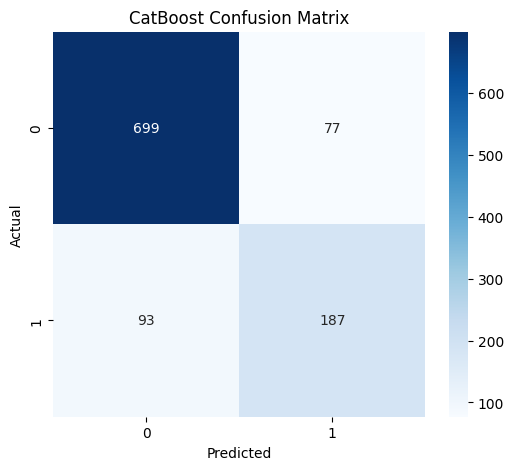

In [78]:
plot_confusion_matrix(best_cat, X_val, y_val, "CatBoost")

In [79]:
best_cat.get_feature_importance(prettified=True)


,Feature Id,Importances
0,Number of Referrals,22.533263
1,Contract_Two Year,16.795717
2,Number of Dependents,11.613012
3,Tenure in Months,7.855316
4,Contract_One Year,6.904271
5,AvgChargePerService,5.365280
6,Age,4.136341
7,Monthly Charge,2.949993
8,Total Long Distance Charges,1.858348
9,Married,1.670373


In [80]:
from sklearn.metrics import roc_curve 
fpr, tpr, thresholds = roc_curve(y_val, y_prob) 
optimal_idx = np.argmax(tpr - fpr) 
optimal_threshold = thresholds[optimal_idx] 
print("Optimal threshold is:", optimal_threshold)

Optimal threshold is: 0.3559493539849056


## Final Model Training

Combining training set and validation

In [81]:
X_final_train = pd.concat([X_train, X_val], axis=0)

y_final_train = pd.concat([y_train, y_val], axis=0)

Training CatBoost Model with the best parameters found

In [82]:
final_cat_model = CatBoostClassifier(
    learning_rate=0.05,
    l2_leaf_reg=3,
    iterations=200,
    depth=4,
    border_count=64,
    verbose=0,
    random_state=42
)

final_cat_model.fit(X_final_train, y_final_train)

CatBoostClassifier(border_count=64, depth=4, iterations=200, l2_leaf_reg=3, learning_rate=0.05, random_state=42, verbose=0)

In [83]:
y_test_prob = final_cat_model.predict_proba(X_test)[:,1]

In [84]:
y_test_pred = (
    y_test_prob >= 0.5
).astype(int)

### Final metrics without threshold optimization

In [85]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_test_pred)

precision = precision_score(y_test, y_test_pred)

recall = recall_score(y_test, y_test_pred)

f1 = f1_score(y_test, y_test_pred)

roc_auc = roc_auc_score(y_test, y_test_prob)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\nClassification Report:\n")

print(classification_report(y_test, y_test_pred))

Accuracy  : 0.8439
Precision : 0.7214
Recall    : 0.6726
F1 Score  : 0.6961
ROC-AUC   : 0.9054

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.91      0.89       776
           1       0.72      0.67      0.70       281

    accuracy                           0.84      1057
   macro avg       0.80      0.79      0.80      1057
weighted avg       0.84      0.84      0.84      1057



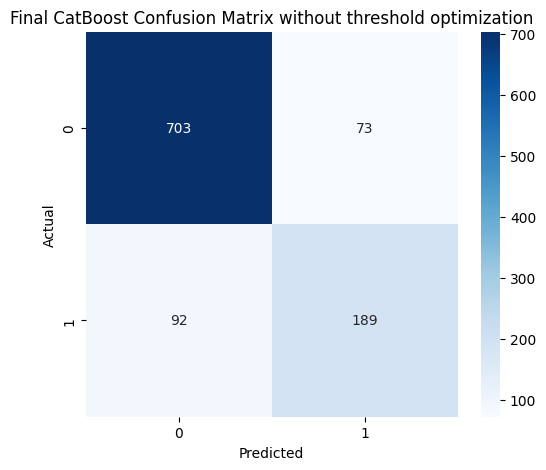

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Final CatBoost Confusion Matrix without threshold optimization')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

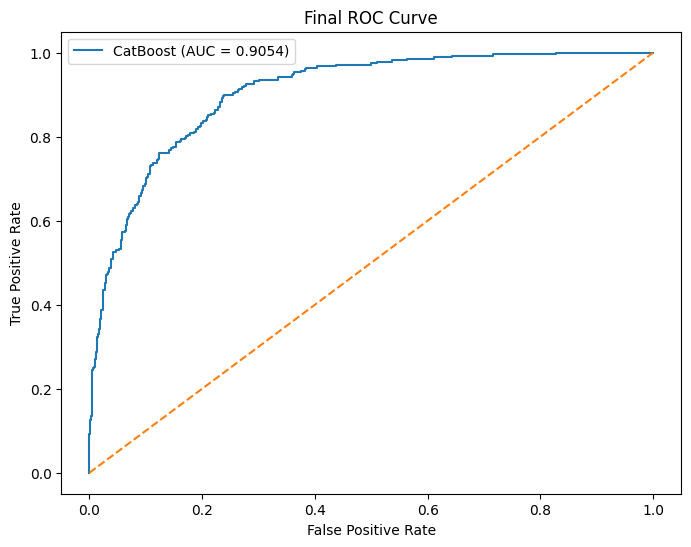

In [87]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_test_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'CatBoost (AUC = {roc_auc:.4f})'
)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title('Final ROC Curve')

plt.legend()

plt.show()

In [88]:
import joblib

joblib.dump(
    final_cat_model,
    'customer_churn_catboost.pkl'
)

['customer_churn_catboost.pkl']

### Final metrics with threshold optimization

In [89]:
optimal_threshold

np.float64(0.3559493539849056)

Threshold optimization

In [90]:
y_test_pred = (
    y_test_prob >= optimal_threshold
).astype(int)

In [91]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_test_pred)

precision = precision_score(y_test, y_test_pred)

recall = recall_score(y_test, y_test_pred)

f1 = f1_score(y_test, y_test_pred)

roc_auc = roc_auc_score(y_test, y_test_prob)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\nClassification Report:\n")

print(classification_report(y_test, y_test_pred))

Accuracy  : 0.8221
Precision : 0.6317
Recall    : 0.7936
F1 Score  : 0.7035
ROC-AUC   : 0.9054

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.83      0.87       776
           1       0.63      0.79      0.70       281

    accuracy                           0.82      1057
   macro avg       0.77      0.81      0.79      1057
weighted avg       0.84      0.82      0.83      1057



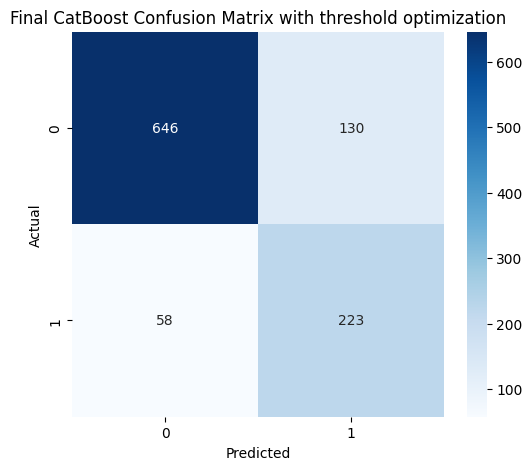

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Final CatBoost Confusion Matrix with threshold optimization')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

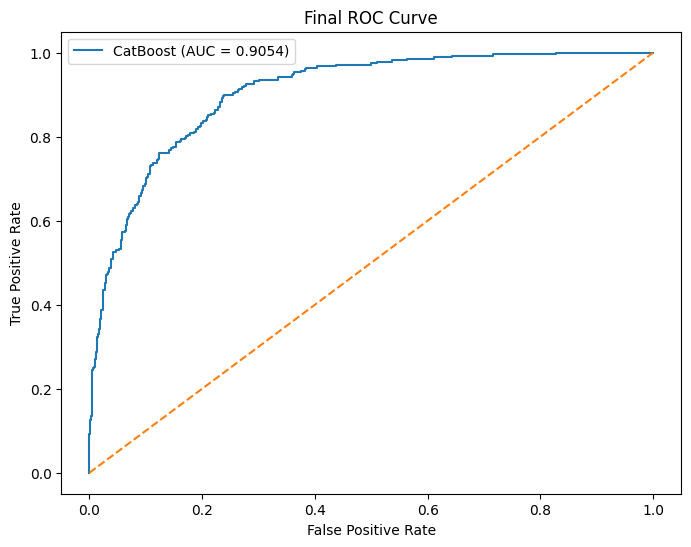

In [93]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_test_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'CatBoost (AUC = {roc_auc:.4f})'
)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title('Final ROC Curve')

plt.legend()

plt.show()

## Threshold Optimization

By default, the model uses a threshold of `0.5` to classify churners.  
After analyzing the ROC Curve, the threshold was optimized to improve churn detection.

| Metric | Default Threshold | Optimized Threshold |
|---|---|---|
| Accuracy | 83.90% | 82.21% |
| Precision | 70.83% | 63.17% |
| Recall | 66.79% | 79.36% |
| F1 Score | 68.75% | 70.35% |
| ROC-AUC | 90.23% | 90.54% |

### Observation

After threshold optimization:

- Recall improved significantly from **66% → 79%**
- The model now catches more actual churners
- Accuracy and precision dropped slightly due to more false positives

Since missing a churn-risk customer is more costly in real business scenarios, the optimized threshold provides a better balance for churn prediction.

In [94]:
import joblib

joblib.dump(
    final_cat_model,
    'customer_churn_catboost.pkl'
)

['customer_churn_catboost.pkl']

In [95]:
joblib.dump(
    optimal_threshold,
    'optimal_threshold.pkl'
)

['optimal_threshold.pkl']

In [105]:
import joblib

joblib.dump(
    X_train.columns.tolist(),
    'model_columns.pkl'
)

['model_columns.pkl']

## SHAP explainability

In [96]:
!pip install shap -q

In [97]:
import shap

In [98]:
explainer = shap.TreeExplainer(final_cat_model)

In [99]:
shap_values = explainer.shap_values(X_test)

### SHAP summary plot

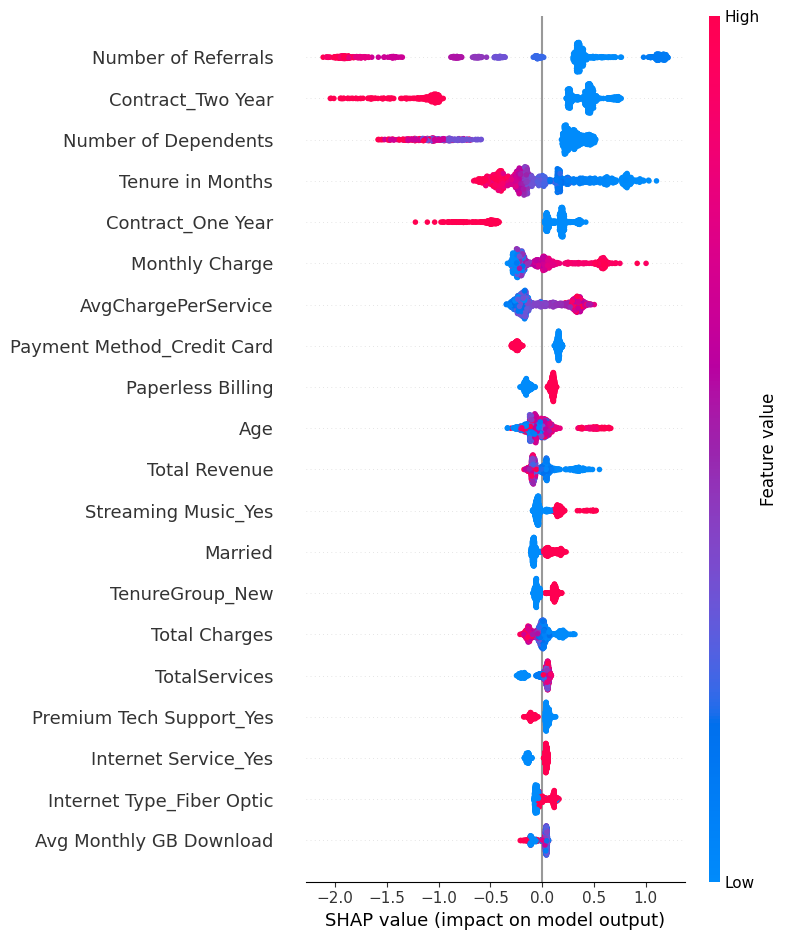

In [100]:
shap.summary_plot(
    shap_values,
    X_test
)

### SHAP Summary Plot Insights

- Customers with fewer referrals were more likely to churn, suggesting that lower engagement may increase the likelihood of leaving.
- Customers with long-term contracts and higher tenure had a lower probability of churn, indicating stronger customer loyalty over time.
- Higher monthly charges were associated with an increased risk of churn, highlighting possible price sensitivity among customers.
- The model identified both customer behavior patterns and billing-related features as strong indicators of churn.

### SHAP Bar Plot

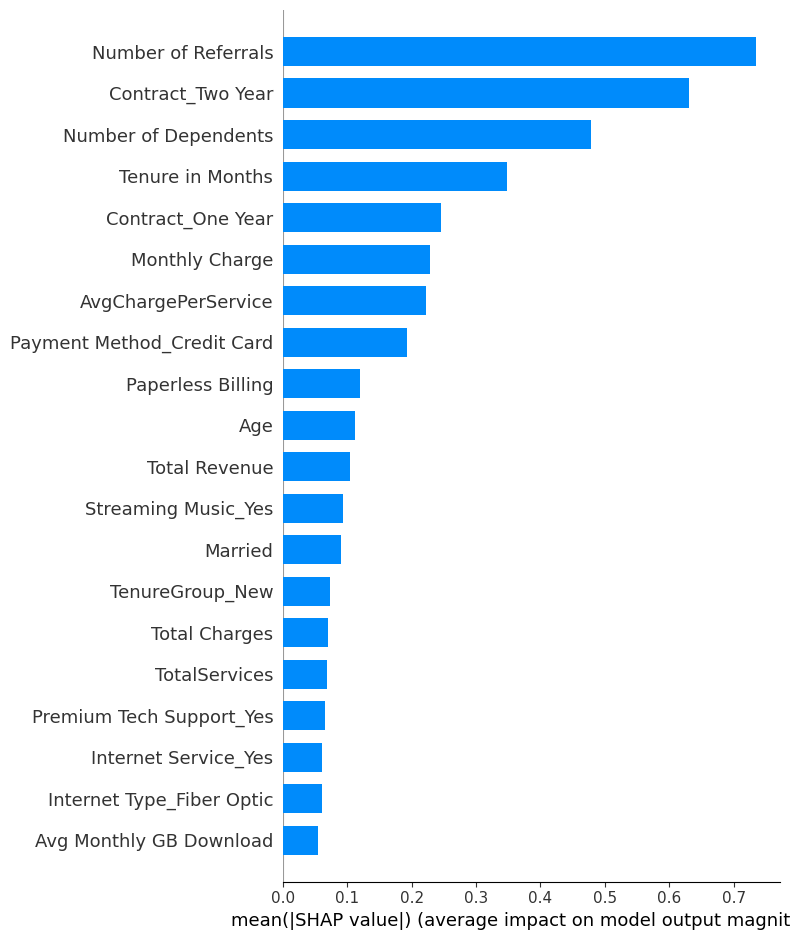

In [101]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar'
)

### SHAP Bar Plot Insights

The model relied heavily on customer loyalty and contract-related features when predicting churn.

- Customers with more referrals and longer contract durations were less likely to churn.
- Lower tenure and higher monthly charges increased the probability of churn.
- Engineered features such as `AvgChargePerService` also contributed significantly to the model’s predictions.

### Waterfall Plot

In [102]:
X_test.iloc[0]

Gender                                     1
Age                                       43
Married                                    0
Number of Dependents                       0
Number of Referrals                        0
Tenure in Months                           5
Phone Service                              1
Avg Monthly Long Distance Charges      38.89
Avg Monthly GB Download                  8.0
Paperless Billing                          0
Monthly Charge                         104.1
Total Charges                          541.9
Total Refunds                            0.0
Total Extra Data Charges                   0
Total Long Distance Charges           194.45
Total Revenue                         736.35
TotalServices                              9
AvgChargePerService                    10.41
AutoPayment                                0
Offer_Offer A                          False
Offer_Offer B                          False
Offer_Offer C                          False
Offer_Offe

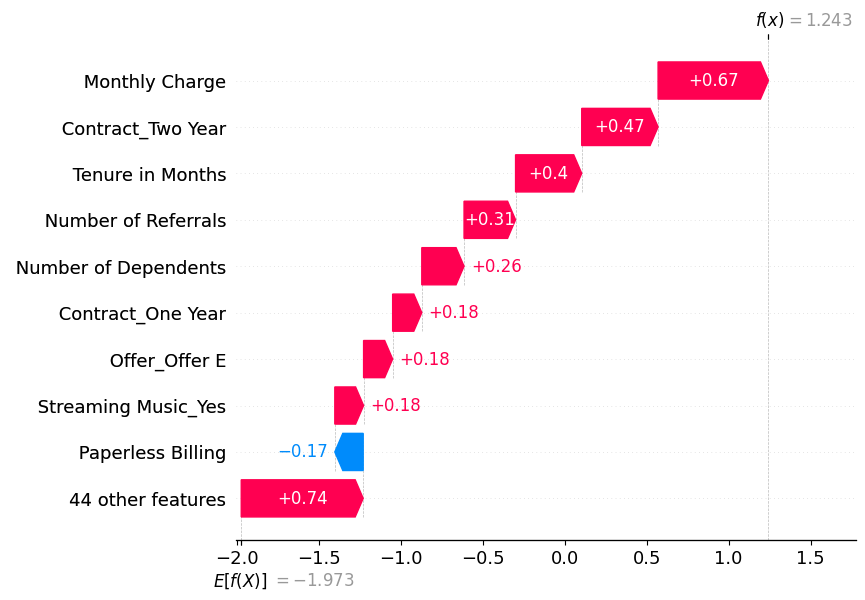

In [103]:
## sample_index=0

shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[sample_index],
    X_test.iloc[sample_index]
)

### SHAP Waterfall Plot

The waterfall plot illustrates how different features influenced the churn prediction for an individual customer.

Positive SHAP values pushed the prediction toward churn, while negative SHAP values reduced the likelihood of churn. This visualization improves model interpretability by clearly showing how each feature contributed to the final prediction for a specific customer.